# 03 — Test our ontology with small examples

Run this notebook from top to bottom. It loads our actual ontology.owl and uses
**invented films and people**, so every expected answer is known in advance.
It does not read TMDB CSVs or modify the ontology.

The existing test_ontology.py checks scope, inverse and chain inference, keyword
typing, and separation of roles from people. Here we make those checks visible
and add failure examples. Each assertion stops execution if an expectation fails.

Passing these examples demonstrates the tested behavior with OWL-RL; it is not
a proof of correctness for every dataset or full OWL consistency/profile validation.

In [58]:
from pathlib import Path
from rdflib import Graph, Namespace, RDF, RDFS, OWL, URIRef
from owlrl import DeductiveClosure, OWLRL_Semantics
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT = next((q for p in candidates for q in (p, p / 'semantic-web')
                if (q / 'ontology/ontology.owl').is_file()), None)
if PROJECT is None:
    raise FileNotFoundError('Cannot locate semantic-web/ontology/ontology.owl')
ontology = Graph().parse(PROJECT / 'ontology/ontology.owl', format='turtle')
S = Namespace('https://schema.org/')
K = Namespace('https://example.org/ontology/')
E = Namespace('https://example.org/test/')
PREFIXES = '''@prefix s: <https://schema.org/> .
@prefix e: <https://example.org/test/> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
'''
checks = []
def check(name, condition):
    assert condition, name
    checks.append(name)
    print('PASS:', name)

def graph_with(data):
    g = Graph()
    for triple in ontology:
        g.add(triple)
    g.parse(data=PREFIXES + data, format='turtle')
    return g

def reason(g):
    result = Graph()
    for triple in g:
        result.add(triple)
    DeductiveClosure(OWLRL_Semantics).expand(result)
    return result

print('Ontology:', PROJECT / 'ontology/ontology.owl')
print('Ontology triples:', len(ontology))

Ontology: c:\Users\admin\Programming\semanticweb\semantic-web\ontology\ontology.owl
Ontology triples: 206


## 1. Check the agreed vocabulary

We expect eight named classes, no company model, and the keyword relationship
to point to DefinedTerm. These checks catch accidental returns to the old model.

In [59]:
expected_classes = {S.Movie, S.Person, S.Role, K.Genre, S.Country,
                    S.Language, S.AggregateRating, S.DefinedTerm}
named_classes = {c for c in ontology.subjects(RDF.type, OWL.Class) if isinstance(c, URIRef)}
check('Exactly the eight agreed named classes', named_classes == expected_classes)
for term in [S.Organization, S.productionCompany, S.location, K.imdbPage,
             K.productionCountry, S.identifier, S.CreativeWork, S.Thing,
             S.Intangible, S.Rating]:
    check('Omitted term: ' + str(term).rsplit('/', 1)[-1],
          not any(term in triple for triple in ontology))
check('Keywords point to DefinedTerm', (S.keywords, RDFS.range, S.DefinedTerm) in ontology)
check('Genres point to kg:Genre', (S.genre, RDFS.range, K.Genre) in ontology)

PASS: Exactly the eight agreed named classes
PASS: Omitted term: Organization
PASS: Omitted term: productionCompany
PASS: Omitted term: location
PASS: Omitted term: imdbPage
PASS: Omitted term: productionCountry
PASS: Omitted term: identifier
PASS: Omitted term: CreativeWork
PASS: Omitted term: Thing
PASS: Omitted term: Intangible
PASS: Omitted term: Rating
PASS: Keywords point to DefinedTerm
PASS: Genres point to kg:Genre


## 2. Tiny input graph

Maya directs Film A, with actor Alex and one acting-role blank node. Film B has
another director and actor. Film B helps detect accidental unrelated results.
Genre, keyword, country, language, and rating nodes deliberately lack explicit
types: the ontology should infer them from property ranges.

In [60]:
data = '''
e:filmA a s:Movie ; s:name "Film A" ; s:director e:maya ;
    s:actor e:alex, [ a s:Role ; s:actor e:alex ;
                     s:characterName "Pilot" ; s:position 0 ] ;
    s:genre e:adventure ; s:keywords e:space ;
    s:countryOfOrigin e:country ; s:inLanguage e:language ;
    s:genre <https://example.org/genre/28>;
    s:duration "PT1H39M"^^xsd:duration ;
    s:aggregateRating [ s:ratingValue 8.2 ; s:ratingCount 200 ] .
e:maya a s:Person ; s:name "Maya" .
e:alex a s:Person ; s:name "Alex" .
e:adventure s:name "Adventure" .
e:space s:name "space" .
e:country s:name "Example country" .
e:language s:name "Example language" .
e:filmB a s:Movie ; s:name "Film B" ; s:director e:lee ; s:actor e:sam .
e:lee a s:Person ; s:name "Lee" .
e:sam a s:Person ; s:name "Sam" .
<https://example.org/genre/28> a s:Genre ;
    s:name "Action" .
'''
print(data)
before = graph_with(data)
after = reason(before)
role = next(before.subjects(RDF.type, S.Role))
rating = next(before.objects(E.filmA, S.aggregateRating))


e:filmA a s:Movie ; s:name "Film A" ; s:director e:maya ;
    s:actor e:alex, [ a s:Role ; s:actor e:alex ;
                     s:characterName "Pilot" ; s:position 0 ] ;
    s:genre e:adventure ; s:keywords e:space ;
    s:countryOfOrigin e:country ; s:inLanguage e:language ;
    s:genre <https://example.org/genre/28>;
    s:duration "PT1H39M"^^xsd:duration ;
    s:aggregateRating [ s:ratingValue 8.2 ; s:ratingCount 200 ] .
e:maya a s:Person ; s:name "Maya" .
e:alex a s:Person ; s:name "Alex" .
e:adventure s:name "Adventure" .
e:space s:name "space" .
e:country s:name "Example country" .
e:language s:name "Example language" .
e:filmB a s:Movie ; s:name "Film B" ; s:director e:lee ; s:actor e:sam .
e:lee a s:Person ; s:name "Lee" .
e:sam a s:Person ; s:name "Sam" .
<https://example.org/genre/28> a s:Genre ;
    s:name "Action" .



In [72]:
inferred = set(after) - set(before)

print(f"Inferred triples: {len(inferred)}")

for s, p, o in sorted(inferred, key=str):
    print(f"{s} -- {p} --> {o}")

Inferred triples: 535
n34ed58fae2384e1e8c2d5011d80960e6b1 -- http://www.w3.org/2000/01/rdf-schema#subClassOf --> n34ed58fae2384e1e8c2d5011d80960e6b1
n34ed58fae2384e1e8c2d5011d80960e6b1 -- http://www.w3.org/2000/01/rdf-schema#subClassOf --> http://www.w3.org/2002/07/owl#Thing
n34ed58fae2384e1e8c2d5011d80960e6b1 -- http://www.w3.org/2002/07/owl#equivalentClass --> n34ed58fae2384e1e8c2d5011d80960e6b1
n34ed58fae2384e1e8c2d5011d80960e6b1 -- http://www.w3.org/2002/07/owl#sameAs --> n34ed58fae2384e1e8c2d5011d80960e6b1
n34ed58fae2384e1e8c2d5011d80960e6b10 -- http://www.w3.org/2002/07/owl#sameAs --> n34ed58fae2384e1e8c2d5011d80960e6b10
n34ed58fae2384e1e8c2d5011d80960e6b11 -- http://www.w3.org/2002/07/owl#sameAs --> n34ed58fae2384e1e8c2d5011d80960e6b11
n34ed58fae2384e1e8c2d5011d80960e6b12 -- http://www.w3.org/2000/01/rdf-schema#subClassOf --> n34ed58fae2384e1e8c2d5011d80960e6b12
n34ed58fae2384e1e8c2d5011d80960e6b12 -- http://www.w3.org/2000/01/rdf-schema#subClassOf --> http://www.w3.org/2002/07/

## 3. Which facts appeared after reasoning?

The table displays only our selected facts, not the reasoner's many vocabulary
and equality triples. Each expected inference must be absent before and present
after reasoning.

In [61]:
expected = [
    ('Maya directed Film A (inverse)', (E.maya, K.directedMovie, E.filmA)),
    ('Maya has cast member Alex (chain)', (E.maya, K.hasCastMember, E.alex)),
    ('Maya has cast role (chain)', (E.maya, K.hasCastMember, role)),
    ('space is a keyword term', (E.space, RDF.type, S.DefinedTerm)),
    ('adventure is a genre', (E.adventure, RDF.type, K.Genre)),
    ('country is a Country', (E.country, RDF.type, S.Country)),
    ('language is a Language', (E.language, RDF.type, S.Language)),
    ('rating is an AggregateRating', (rating, RDF.type, S.AggregateRating)),
]
rows = ['| Fact | Before | After |', '|---|---|---|']
for label, triple in expected:
    rows.append(f'| {label} | {triple in before} | {triple in after} |')
    check(label, triple not in before and triple in after)
display(Markdown('\n'.join(rows)))
check('Role did not become a Person', (role, RDF.type, S.Person) not in after)
check('Role did not become a Movie', (role, RDF.type, S.Movie) not in after)
check('Maya did not acquire Film B actor Sam', (E.maya, K.hasCastMember, E.sam) not in after)

PASS: Maya directed Film A (inverse)
PASS: Maya has cast member Alex (chain)
PASS: Maya has cast role (chain)
PASS: space is a keyword term
PASS: adventure is a genre
PASS: country is a Country
PASS: language is a Language
PASS: rating is an AggregateRating


| Fact | Before | After |
|---|---|---|
| Maya directed Film A (inverse) | False | True |
| Maya has cast member Alex (chain) | False | True |
| Maya has cast role (chain) | False | True |
| space is a keyword term | False | True |
| adventure is a genre | False | True |
| country is a Country | False | True |
| language is a Language | False | True |
| rating is an AggregateRating | False | True |

PASS: Role did not become a Person
PASS: Role did not become a Movie
PASS: Maya did not acquire Film B actor Sam


## 4. Visualize the director-to-cast inference

Solid lines are input facts; dashed lines are derived facts. The diagram only
draws a selected part of the example. Role targets are valid too, so queries
listing people must explicitly filter for Person.

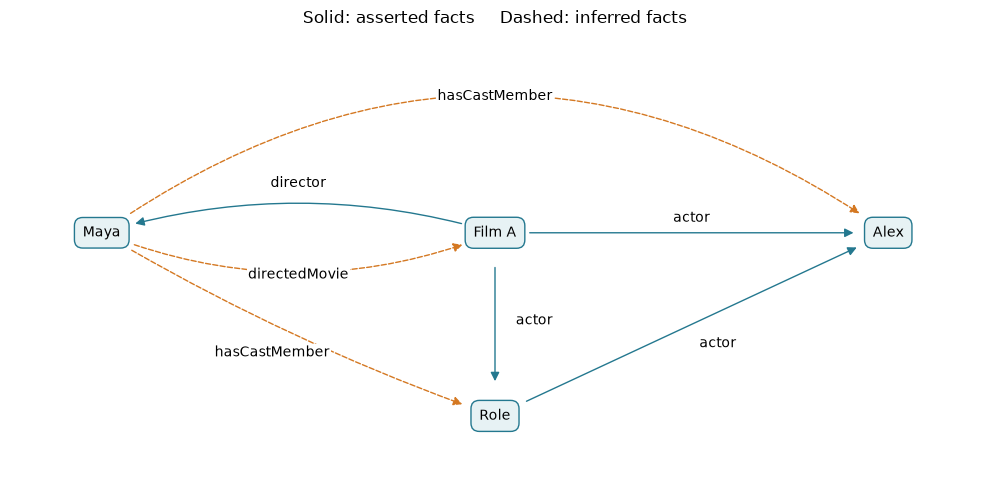

In [62]:
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(10, 5))
positions = {'Maya': (0, 1), 'Film A': (3, 1), 'Alex': (6, 1), 'Role': (3, -1)}
edges = [
 ('Film A', 'Maya', 'director', False, .15),
 ('Maya', 'Film A', 'directedMovie', True, .2),
 ('Film A', 'Alex', 'actor', False, 0),
 ('Film A', 'Role', 'actor', False, 0),
 ('Role', 'Alex', 'actor', False, 0),
 ('Maya', 'Alex', 'hasCastMember', True, -.35),
 ('Maya', 'Role', 'hasCastMember', True, .05),
]
for source, target, label, inferred, curve in edges:
    a, b = positions[source], positions[target]
    ax.add_patch(FancyArrowPatch(a, b, connectionstyle=f'arc3,rad={curve}',
                                arrowstyle='-|>', mutation_scale=13, shrinkA=25, shrinkB=25,
                                linestyle='--' if inferred else '-',
                                color='#d47822' if inferred else '#24788f'))
labels = [(1.5,1.5,'director'), (1.5,.5,'directedMovie'),
          (4.5,1.12,'actor'), (3.3,0,'actor'), (4.7,-.25,'actor'),
          (3,2.45,'hasCastMember'), (1.3,-.35,'hasCastMember')]
for x,y,label in labels:
    ax.text(x,y,label,ha='center',fontsize=10,bbox=dict(facecolor='white',edgecolor='none',pad=1))
for label, (x,y) in positions.items():
    ax.text(x,y,label,ha='center',va='center',bbox=dict(boxstyle='round,pad=.6',fc='#e7f2f4',ec='#24788f'))
ax.set(xlim=(-.7,6.7),ylim=(-1.7,3.2))
ax.axis('off')
ax.set_title('Solid: asserted facts     Dashed: inferred facts')
plt.tight_layout()
plt.show()

## 5. Prove a SPARQL answer changes

The same query is run before and after reasoning. Before: no hasCastMember
facts. After: Alex, and only Alex, for Maya. The Role node is excluded by type.
A second query uses stored ratings and keywords without needing inference.

In [63]:
query = '''
PREFIX s: <https://schema.org/>
PREFIX k: <https://example.org/ontology/>
PREFIX e: <https://example.org/test/>
SELECT DISTINCT ?actor ?name WHERE {
  e:maya k:hasCastMember ?actor .
  ?actor a s:Person ; s:name ?name .
}
'''
print(query)
before_rows = {(str(r.actor), str(r.name)) for r in before.query(query)}
after_rows = {(str(r.actor), str(r.name)) for r in after.query(query)}
print('Before:', before_rows)
print('After:', after_rows)
check('Exact inferred actor query result', before_rows == set() and after_rows == {(str(E.alex), 'Alex')})
rating_query = '''
PREFIX s: <https://schema.org/>
SELECT ?title WHERE {
  ?movie s:name ?title ; s:keywords ?keyword ; s:aggregateRating ?rating .
  ?keyword s:name "space" .
  ?rating s:ratingValue ?value ; s:ratingCount ?votes .
  FILTER (?value >= 8 && ?votes >= 100)
}
'''
check('Keyword + rating query works on explicit facts',
      [str(r.title) for r in before.query(rating_query)] == ['Film A'])


PREFIX s: <https://schema.org/>
PREFIX k: <https://example.org/ontology/>
PREFIX e: <https://example.org/test/>
SELECT DISTINCT ?actor ?name WHERE {
  e:maya k:hasCastMember ?actor .
  ?actor a s:Person ; s:name ?name .
}

Before: set()
After: {('https://example.org/test/alex', 'Alex')}
PASS: Exact inferred actor query result
PASS: Keyword + rating query works on explicit facts


## 6. A Role path does not imply a direct actor edge

This isolated example has only Movie → Role → Person. Our ontology does not
declare actor transitive or provide a rule to collapse this path. The future
transformer must write the direct actor edge as agreed.

In [64]:
indirect = reason(graph_with('''
e:film a s:Movie ; s:name "Indirect example" ;
    s:actor [ a s:Role ; s:actor e:person ] .
e:person a s:Person .
'''))
check('Two-step actor path does not create a direct actor edge',
      (E.film, S.actor, E.person) not in indirect)

PASS: Two-step actor path does not create a direct actor edge


## 7. Deliberately wrong data: a movie that is also a person

The small checker below finds individuals typed as two declared disjoint
classes, treating the disjoint pair symmetrically. It is a targeted conflict
check, not a full OWL consistency checker. The invalid graph remains separate
from the valid example.

In [65]:
def disjoint_conflicts(g):
    conflicts = set()
    for left, right in ontology.subject_objects(OWL.disjointWith):
        for node in set(g.subjects(RDF.type, left)) & set(g.subjects(RDF.type, right)):
            conflicts.add((str(node), *sorted([str(left), str(right)])))
    return conflicts

check('Valid example has no disjoint-type conflicts', not disjoint_conflicts(after))
invalid = reason(graph_with('e:wrong a s:Movie, s:Person .'))
conflicts = disjoint_conflicts(invalid)
print('Detected conflicts:', sorted(conflicts))
check('Bad Movie + Person typing is detected',
      any(row[0] == str(E.wrong) for row in conflicts))
keyword_conflict = reason(graph_with('e:wrong a s:Movie, s:DefinedTerm .'))
check('Movie + keyword conflict is detected regardless of declaration direction',
      bool(disjoint_conflicts(keyword_conflict)))

PASS: Valid example has no disjoint-type conflicts
Detected conflicts: [('https://example.org/test/wrong', 'https://schema.org/Movie', 'https://schema.org/Person')]
PASS: Bad Movie + Person typing is detected
PASS: Movie + keyword conflict is detected regardless of declaration direction


## 8. Cardinality: two rating nodes can become equal

Movie has at most one aggregateRating in our ontology. If two resource names
are supplied, OWL can infer that they refer to the same rating. Different URIs
are not automatically different individuals. This is why OWL cardinality is
not a duplicate-row validator.

In [66]:
two_ratings = reason(graph_with('''
e:film a s:Movie ; s:name "Two labels" ; s:aggregateRating e:r1, e:r2 .
'''))
check('At-most-one rating implies equality of two rating resources',
      (E.r1, OWL.sameAs, E.r2) in two_ratings)
print('Inferred:', E.r1, 'owl:sameAs', E.r2)

PASS: At-most-one rating implies equality of two rating resources
Inferred: https://example.org/test/r1 owl:sameAs https://example.org/test/r2


## 9. Missing names require a separate completeness check

A minimum-name restriction does not invent a name literal or act like a CSV
NOT NULL check. We can find missing names with SPARQL explicitly. Detecting
such missing data is separate from logical inference.

In [67]:
missing = reason(graph_with('e:unnamed a s:Movie .'))
check('Reasoning does not invent a name', not list(missing.objects(E.unnamed, S.name)))
missing_query = '''
PREFIX s: <https://schema.org/>
SELECT ?movie WHERE {
  ?movie a s:Movie .
  FILTER NOT EXISTS { ?movie s:name ?name }
}
'''
missing_movies = {r.movie for r in missing.query(missing_query)}
check('Explicit completeness query finds the unnamed movie', E.unnamed in missing_movies)
print('Missing-name report:', sorted(map(str, missing_movies)))

PASS: Reasoning does not invent a name
PASS: Explicit completeness query finds the unnamed movie
Missing-name report: ['https://example.org/test/unnamed']


## 10. schema:sameAs versus owl:sameAs

Our schema:sameAs is an ordinary reference-link property. It does not merge
resources or propagate their properties. OWL's sameAs asserts identity and
does allow propagation. These examples use local invented resources; no remote
data is downloaded.

In [68]:
reference_link = reason(graph_with('''
e:local s:sameAs e:external .
e:external s:name "External title" .
'''))
identity_link = reason(graph_with('''
e:local owl:sameAs e:external .
e:external s:name "External title" .
'''))
check('schema:sameAs does not propagate the title', not list(reference_link.objects(E.local, S.name)))
check('schema:sameAs is not declared symmetric',
      (E.external, S.sameAs, E.local) not in reference_link)
check('owl:sameAs propagates the title',
      {str(x) for x in identity_link.objects(E.local, S.name)} == {'External title'})

PASS: schema:sameAs does not propagate the title
PASS: schema:sameAs is not declared symmetric
PASS: owl:sameAs propagates the title


## Results

The assertions above establish expected behavior for these particular examples:
vocabulary scope, typing, inverse and chain inference, exact SPARQL results,
role separation, disjointness conflicts, equality, and completeness checks.
They do not test the future transformer or prove correctness for every graph.
Keep the small examples as regression checks when editing the ontology.

In [69]:
print(f'All {len(checks)} checks passed.')
for i, name in enumerate(checks, 1):
    print(f'{i:02}. {name}')

All 36 checks passed.
01. Exactly the eight agreed named classes
02. Omitted term: Organization
03. Omitted term: productionCompany
04. Omitted term: location
05. Omitted term: imdbPage
06. Omitted term: productionCountry
07. Omitted term: identifier
08. Omitted term: CreativeWork
09. Omitted term: Thing
10. Omitted term: Intangible
11. Omitted term: Rating
12. Keywords point to DefinedTerm
13. Genres point to kg:Genre
14. Maya directed Film A (inverse)
15. Maya has cast member Alex (chain)
16. Maya has cast role (chain)
17. space is a keyword term
18. adventure is a genre
19. country is a Country
20. language is a Language
21. rating is an AggregateRating
22. Role did not become a Person
23. Role did not become a Movie
24. Maya did not acquire Film B actor Sam
25. Exact inferred actor query result
26. Keyword + rating query works on explicit facts
27. Two-step actor path does not create a direct actor edge
28. Valid example has no disjoint-type conflicts
29. Bad Movie + Person typing 